In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
from sklearn.neighbors import KDTree
from sklearn.neighbors import NearestNeighbors

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import render
from src import postprocess as _postprocess

import types

import DriftCorrectionFunctions as DCF


smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20260214_102327.log
/tmp/ipykernel_972388/4092582263.py:29: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
folder = '/media/jbeckwith/Ezra Seagat/20260213_Diradical_Ritu/'

In [3]:
data_NoDiradical_WithTubulin = H_F.file_search(folder, '.tif', '_Alone')




data_WithDiradical_WithTubulin = H_F.file_search(folder, '.tif', 'andDiradical')



'CytoskeletonStain_Position0000_MIP.svg'

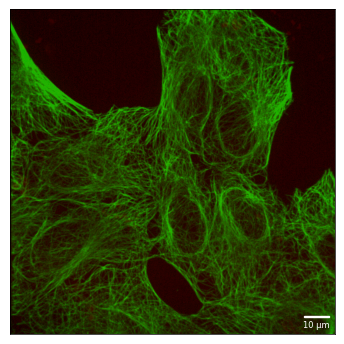

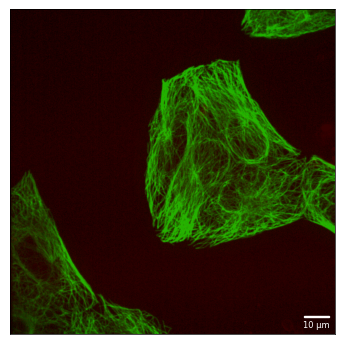

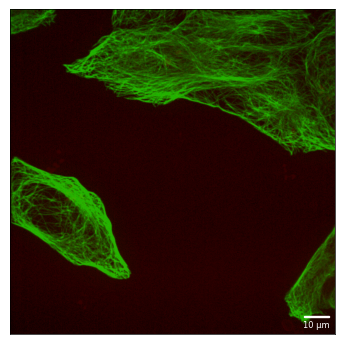

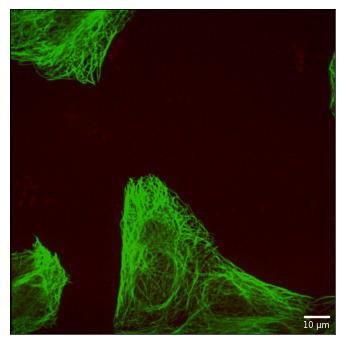

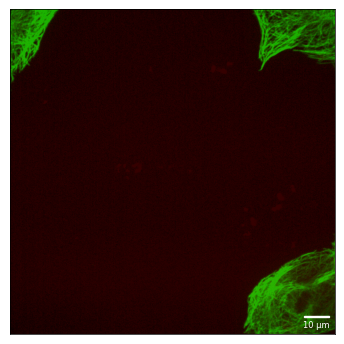

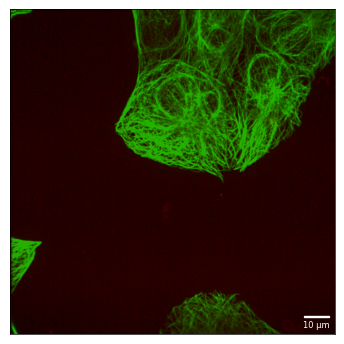

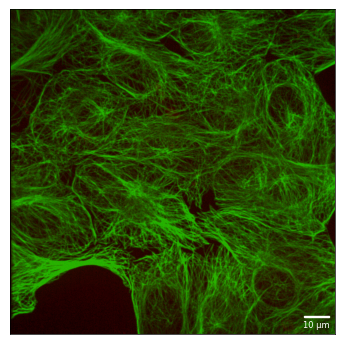

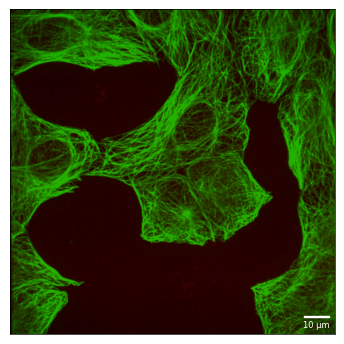

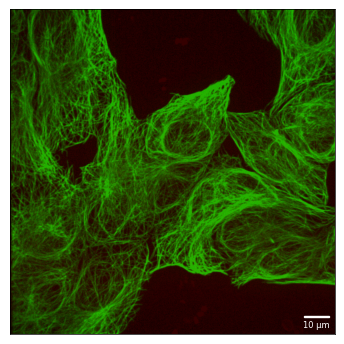

In [37]:


from PlottingBase import PublicationPlotter

for file in data_NoDiradical_WithTubulin:

    data = IO.read_hyperstack(file)[0]
    img1 = np.max(data[:, 0, :, :], axis=0)
    img2 = np.max(data[:, 1, :, :], axis=0)
    # Create overlay
    plotter = PublicationPlotter()
    fig, ax = plotter.one_column_plot()
    
    pixel_size = 110
    oversampling = 1
    
    plotter.multichannel_overlay_plot(
      ax, [img2, img1],
      cmaps=['red', 'green'],
      pixelsize=(pixel_size/oversampling),
      scalebarsize=10000,
      vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
      vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
      brightness_boost=[2, 1],
      scalebarlabel='10 μm'
    )
    savefile = os.path.join('/media/jbeckwith/Ezra Seagat/20260213_Diradical_Ritu/Figures/Cytoskeleton_Alone/', 
                            os.path.split(file)[-1].split('.tif')[0]+'_MIP.svg')
    plt.savefig(savefile, dpi=300, format='svg')
    plt.show()

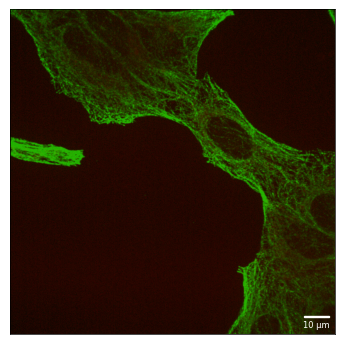

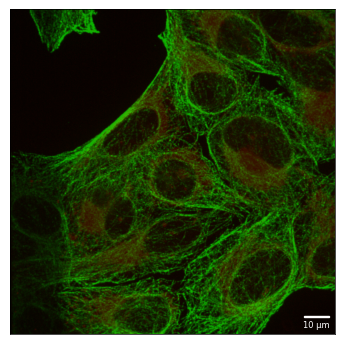

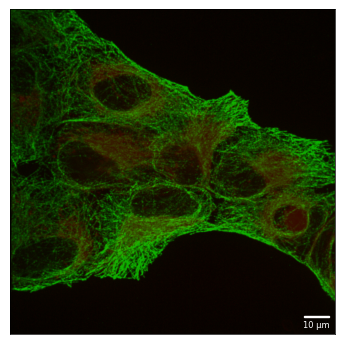

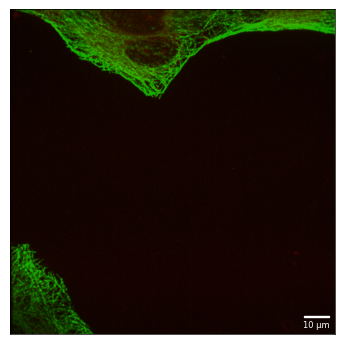

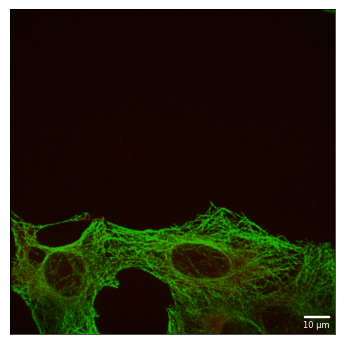

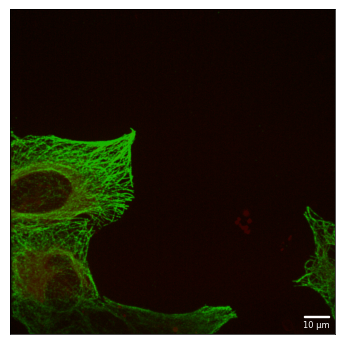

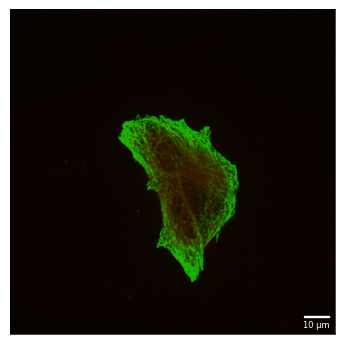

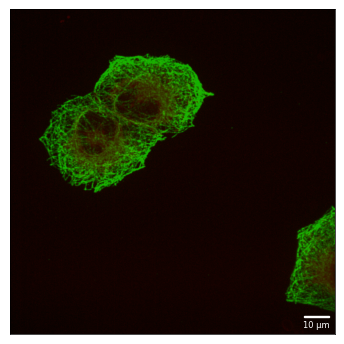

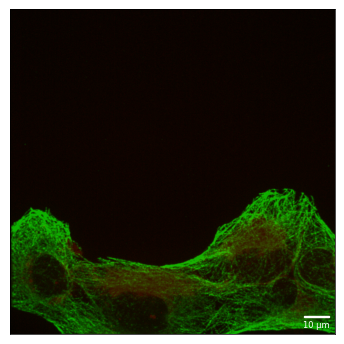

In [38]:


from PlottingBase import PublicationPlotter

for file in data_WithDiradical_WithTubulin:

    data = IO.read_hyperstack(file)[0]
    img1 = np.max(data[:, 0, :, :], axis=0)
    img2 = np.max(data[:, 1, :, :], axis=0)
    # Create overlay
    plotter = PublicationPlotter()
    fig, ax = plotter.one_column_plot()
    
    pixel_size = 110
    oversampling = 1
    
    plotter.multichannel_overlay_plot(
      ax, [img2, img1],
      cmaps=['red', 'green'],
      pixelsize=(pixel_size/oversampling),
      scalebarsize=10000,
      vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
      vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
      brightness_boost=[2, 1],
      scalebarlabel='10 μm'
    )
    savefile = os.path.join('/media/jbeckwith/Ezra Seagat/20260213_Diradical_Ritu/Figures/CytoskeletonStain_and_Diradical/', 
                            os.path.split(file)[-1].split('.tif')[0]+'_MIP.svg')
    plt.savefig(savefile, dpi=300, format='svg')
    plt.show()

In [ ]:
data = IO.read_tiff(os.path.join(folder, 'Conc_Diradical_405exc_XY1769952876_Z0_T000_C0.tif'))

In [ ]:
np.median(data, axis=0).shape

In [ ]:
data_MF = data - np.median(data, axis=0)

In [ ]:
np.percentile(data_MF, 99.9)

In [ ]:
plotter.make_animated_gif_image(image=data_MF[:80, :, :], n_frames=80, filename='output.gif', vmin=-16.0,
                                vmax=19.0, pixelsize=110, scalebarsize=10000, scalebarlabel='10 µm')

In [34]:
dirad = 'U2OS_Diradical_HighDensity_RedCellMask_XY1765894206_Z00_T0'

data_C0_filt = np.sort([x for x in data_C0 if dirad in x])
data_C1_filt = np.sort([x for x in data_C1 if dirad in x])

from PlottingBase import PublicationPlotter

for i in np.arange(len(data_C1_filt)):
    image_C0 = IO.read_tiff(data_C0_filt[i])
    image_C1 = IO.read_tiff(data_C1_filt[i])
    
    
    img1 = np.max(image_C0, axis=0)
    img2 = np.max(image_C1, axis=0)
    
    # Create overlay
    plotter = PublicationPlotter()
    fig, ax = plotter.one_column_plot()
    
    pixel_size = 110
    oversampling = 1
    
    plotter.multichannel_overlay_plot(
      ax, [img2, img1],
      cmaps=['green', 'darkred'],
      pixelsize=(pixel_size/oversampling),
      scalebarsize=10000,
      vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
      vmaxs=[np.percentile(img2, 95), np.percentile(img1, 99)],
      brightness_boost=[1, 1.5],
      scalebarlabel='10 μm'
    )
    
    folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260108/fig/Diradicals/'
    name = os.path.split(data_C0_filt[i])[1].split('C0.tif')[0]+'MIP'
    plt.savefig(os.path.join(folder, name+'.svg'), dpi=300, format='svg')
    plt.show()

NameError: name 'data_C0' is not defined

In [ ]:
nodirad = 'U2OS_Well6_NoDiradical_Magnet - Position 1 [9]_XY1765901174_Z00_T4'

data_C0_filt = np.sort([x for x in data_C0 if nodirad in x])
data_C1_filt = np.sort([x for x in data_C1 if nodirad in x])

from PlottingBase import PublicationPlotter

for i in np.arange(len(data_C1_filt)):
    image_C0 = IO.read_tiff(data_C0_filt[i])
    image_C1 = IO.read_tiff(data_C1_filt[i])
    
    
    img1 = np.max(image_C0, axis=0)
    img2 = np.max(image_C1, axis=0)
    
    # Create overlay
    plotter = PublicationPlotter()
    fig, ax = plotter.one_column_plot()
    
    pixel_size = 110
    oversampling = 1
    
    plotter.multichannel_overlay_plot(
      ax, [img2, img1],
      cmaps=['green', 'darkred'],
      pixelsize=(pixel_size/oversampling),
      scalebarsize=10000,
      vmins=[np.percentile(img2, 1), np.percentile(img1, 1)],
      vmaxs=[np.percentile(img2, 99), np.percentile(img1, 99)],
      brightness_boost=[1, 1.5],
      scalebarlabel='10 μm'
    )
    
    folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260108/fig/Diradicals/'
    name = os.path.split(data_C0_filt[i])[1].split('C0.tif')[0]+'MIP'
    plt.savefig(os.path.join(folder, name+'.svg'), dpi=300, format='svg')
    plt.show()

In [ ]:
import numpy as np
import napari
from napari_animation import Animation

# Create or load your image stacks
# image_C0 and image_C1 should be your 3D image arrays
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260108/fig/Diradicals/'

dirad = 'U2OS_Diradical_HighDensity_RedCellMask_XY1765894206_Z00_T0'

data_C0_filt = np.sort([x for x in data_C0 if dirad in x])
data_C1_filt = np.sort([x for x in data_C1 if dirad in x])

for file_index in np.arange(len(data_C1_filt)):
    image_C0 = IO.read_tiff(data_C0_filt[file_index])
    image_C1 = IO.read_tiff(data_C1_filt[file_index])

    combined_stacks = np.stack([image_C0, image_C1], axis=0)
    
    # View with napari, specifying channel axis and colors
    viewer = napari.view_image(
        combined_stacks.astype(float),
        channel_axis=0,  # First dimension is now channels
        name=['radicals', 'cellmask'],  # Layer names
        colormap=['darkred', 'green'],  # Color for each channel
        blending='additive',  # Allows colors to combine
        contrast_limits=[(0, np.percentile(image_C0, 99)), (np.percentile(image_C1, 1), np.percentile(image_C1, 99.9))],  # Adjust based on your data
        scale=[0.5, 0.11, 0.11],
    )
    
    # Switch to 3D rendering
    viewer.dims.ndisplay = 3
    
    # Apply rendering settings
    rendering_settings = {
        'rendering': 'iso',
        'attenuation': 0.1,  # Light penetration
        'gamma': 0.7,  # Gamma correction
    }
    
    viewer.layers[0].opacity = 0.9  # Red - start high
    viewer.layers[1].opacity = 0.3  # Green - start low
    
    for i, layer in enumerate(viewer.layers):
        # Apply base settings
        for key, value in rendering_settings.items():
            setattr(layer, key, value)
        
        # Channel-specific thresholds
        data = combined_stacks[i]
        
        # More robust threshold calculation
        if np.max(data) > 0:
            # Use percentiles of non-zero values
            non_zero = data[data > 0]
            if len(non_zero) > 0:
                layer.iso_threshold = np.percentile(non_zero, 85)
            else:
                layer.iso_threshold = np.percentile(data, 90)
        else:
            layer.iso_threshold = np.percentile(data, 90)
    
    # Set initial camera view
    viewer.camera.angles = (0, 0, 90)
    viewer.camera.zoom = 3.0  # Slight zoom for better framing
    
    # Create animation with multiple keyframes for smooth rotation
    animation = Animation(viewer)
    
    # Capture starting keyframe
    animation.capture_keyframe()
    
    # Define rotation path - rotating around Y axis for better 3D effect
    keyframes = [
        (0, 45, 90),    # 45° around Y
        (0, 135, 90),   # 135° around Y
        (0, 225, 90),   # 225° around Y  
        (0, 315, 90),   # 315° around Y
        (0, 360, 90),   # Complete 360° (back to start)
    ]
    name = os.path.split(data_C0_filt[file_index])[1].split('C0.tif')[0]+'rotating_3d_render.gif'
    # Capture each keyframe with smooth transitions
    for angles in keyframes:
        viewer.camera.angles = angles
        animation.capture_keyframe(steps=45)  # 45 frames between each keyframe
    
    # Generate the GIF - use canvas_only=True to capture only the render
    try:
        animation.animate(
            os.path.join(folder, name), 
            canvas_only=True,  # This should capture only the 3D render, not the UI
            fps=20,            # 20 FPS for smooth but not too fast rotation
        )
        print("✅ Animation saved as 'rotating_3d_render.gif'")
    except Exception as e:
        print(f"❌ Error saving animation: {e}")
        print("Trying alternative approach...")
        
        # Fallback: try without canvas_only
        animation.animate(
            os.path.join(folder, name), 
            canvas_only=False,
            fps=20,
        )
        print("✅ Animation saved with fallback method")
    viewer.close()
    print("Animation complete! The GIF should show a smooth 360° rotation around the Y-axis.")

In [ ]:
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260108/fig/Diradicals/'
files = H_F.file_search(folder, '.png', '')

In [ ]:
for file in files:
    os.remove(file)